Loan prediction systems have become an essential application of machine learning in the banking and financial sector. Financial institutions use predictive analytics to determine whether a loan applicant is likely to repay the loan or default. By analyzing customer-related factors such as income, credit score, employment status, age, and loan amount, machine learning models help improve decision-making accuracy and reduce financial risk.

The dataset used in this study contains 2,000 records and 7 variables, including applicant demographics and financial information. The target variable is Loan_Approved, which indicates whether the loan was approved or not.

| Variable          | Description                       |
| ----------------- | --------------------------------- |
| Age               | Age of the applicant              |
| Income            | Annual income of the customer     |
| Credit_Score      | Creditworthiness score            |
| Loan_Amount       | Amount requested for loan         |
| Loan_Term         | Duration of loan repayment        |
| Employment_Status | Employment category               |
| Loan_Approved     | Target variable (0 = No, 1 = Yes) |



# loan_approval Determination Factors

| Feature               | Impact on Loan Approval                                                |
| --------------------- | ---------------------------------------------------------------------- |
| **Credit_Score**      | Most important factor. Higher credit scores increase approval chances. |
| **Income**            | Applicants with higher income are more likely to get loans approved.   |
| **Employment_Status** | Stable employment improves approval probability.                       |
| **Loan_Amount**       | Very high loan amounts may reduce approval chances.                    |
| **Loan_Term**         | Longer loan terms can increase lending risk.                           |
| **Age**               | Financially stable age groups usually receive easier approvals.        |


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
df=pd.read_csv('loan_prediction_dataset.csv')
df

,Age,Income,Credit_Score,Loan_Amount,Loan_Term,Employment_Status,Loan_Approved
0,56,81788,334,15022,48,Employed,0
1,69,102879,781,21013,24,Self-Employed,1
2,46,58827,779,39687,60,Self-Employed,0
3,32,127188,364,16886,24,Unemployed,0
4,60,25655,307,26256,36,Unemployed,0
...,...,...,...,...,...,...,...
1995,63,87580,761,29716,48,Employed,1
1996,67,27368,695,13601,36,Employed,0
1997,69,105436,636,37018,36,Self-Employed,0
1998,24,116136,441,9061,48,Employed,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Age                2000 non-null   int64 
 1   Income             2000 non-null   int64 
 2   Credit_Score       2000 non-null   int64 
 3   Loan_Amount        2000 non-null   int64 
 4   Loan_Term          2000 non-null   int64 
 5   Employment_Status  2000 non-null   object
 6   Loan_Approved      2000 non-null   int64 
dtypes: int64(6), object(1)
memory usage: 109.5+ KB


In [4]:
# Change Loan_Approved values from 1,0 to Yes,No

df['Loan_Approved'] = df['Loan_Approved'].replace({
    1: 'Yes',
    0: 'No'
})

# Check updated values
print(df['Loan_Approved'].head())

0     No
1    Yes
2     No
3     No
4     No
Name: Loan_Approved, dtype: object


- The replace() function is used to convert numerical values in the Loan_Approved column into readable categorical values.
- Here, 1 is replaced with "Yes" and 0 is replaced with "No" for better understanding and visualization.
- Finally, head() displays the first few updated records to verify the changes successfully.

# **Univariate Analysis**

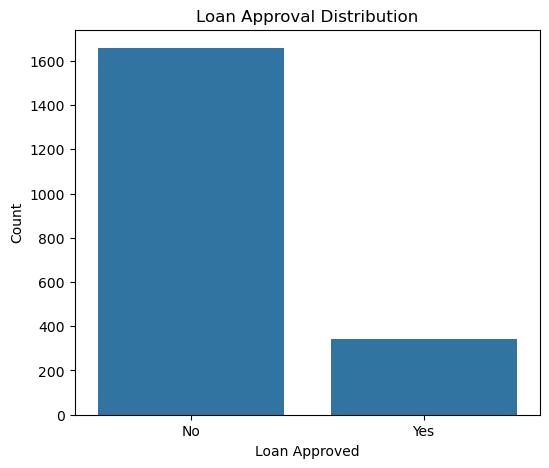

In [5]:
plt.figure(figsize=(6,5))

sns.countplot(
    x='Loan_Approved',
    data=df
)

plt.title("Loan Approval Distribution")
plt.xlabel("Loan Approved")
plt.ylabel("Count")

plt.show()

 - Around 1650 loan applications were rejected (No), while only about 350 loans were approved (Yes).
- The graph clearly shows that rejected loans are much higher than approved loans in the dataset.
- This indicates an imbalanced dataset where most applicants did not receive loan approval.

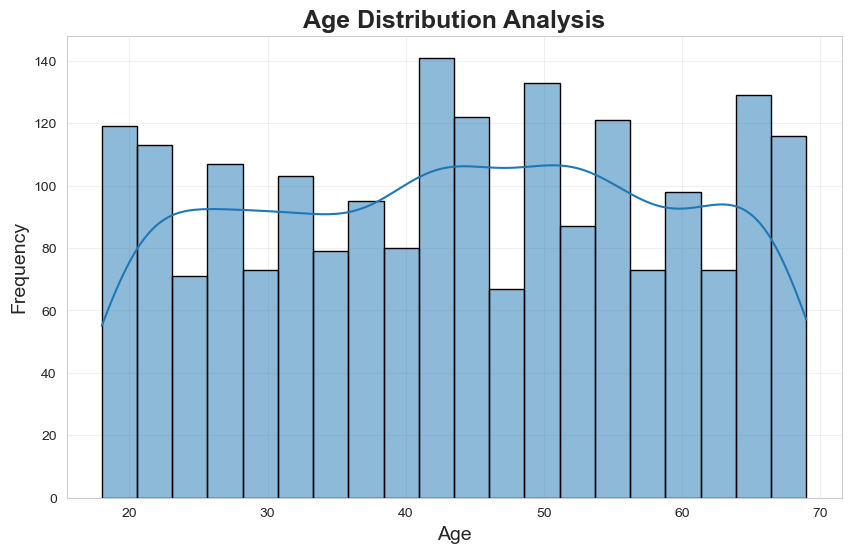

In [6]:
# Style
sns.set_style("whitegrid")

# Create Figure
plt.figure(figsize=(10,6))

# Histogram + KDE
sns.histplot(
    data=df,
    x='Age',
    bins=20,
    kde=True,
    edgecolor='black'
)

# Titles and Labels
plt.title('Age Distribution Analysis', fontsize=18, fontweight='bold')
plt.xlabel('Age', fontsize=14)
plt.ylabel('Frequency', fontsize=14)

# Grid Styling
plt.grid(alpha=0.3)

# Show Plot
plt.show()

## Findings
- The distribution of applicants’ age is moderately uniform across the range of 18–70 years, with higher concentrations observed between 40–55 years.

- The frequency peaks at approximately 140 observations, indicating that middle-aged applicants constitute a significant portion of the dataset.

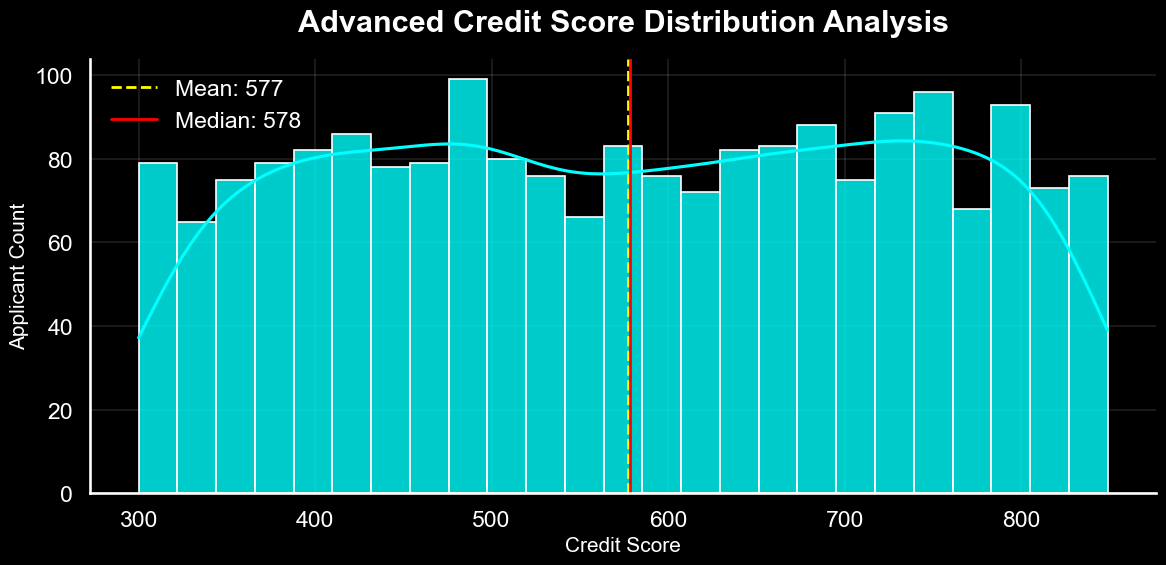

In [7]:
# Modern Style
plt.style.use('dark_background')
sns.set_context("talk")

# Create Figure
fig, ax = plt.subplots(figsize=(12,6))

# Gradient Histogram + KDE
sns.histplot(
    data=df,
    x='Credit_Score',
    bins=25,
    kde=True,
    color='cyan',
    edgecolor='white',
    linewidth=1.2,
    alpha=0.8,
    ax=ax
)

# Mean & Median Lines
mean_score = df['Credit_Score'].mean()
median_score = df['Credit_Score'].median()

ax.axvline(mean_score, color='yellow', linestyle='--', linewidth=2, label=f'Mean: {mean_score:.0f}')
ax.axvline(median_score, color='red', linestyle='-', linewidth=2, label=f'Median: {median_score:.0f}')

# Titles
ax.set_title('Advanced Credit Score Distribution Analysis', fontsize=22, fontweight='bold', pad=20)
ax.set_xlabel('Credit Score', fontsize=15)
ax.set_ylabel('Applicant Count', fontsize=15)

# Glow Grid Effect
ax.grid(color='white', alpha=0.1)

# Legend
ax.legend(frameon=False)

# Remove top/right border
sns.despine()

# Show Graph
plt.tight_layout()
plt.show()

## Findings
- The credit score distribution is centered around a mean of 577 and a median of 578, indicating a nearly symmetrical distribution with minimal skewness.

- Most applicants fall within the 400–800 credit score range, with peak applicant counts approaching 100 observations across multiple score intervals.

========== Loan Amount Statistics ==========
count     2000.000000
mean     25460.315000
std      14116.737774
min       1060.000000
25%      13444.250000
50%      25446.000000
75%      37949.250000
max      49994.000000
Name: Loan_Amount, dtype: float64

Mean Loan Amount   : 25460.31
Median Loan Amount : 25446.00
Mode Loan Amount   : 2462


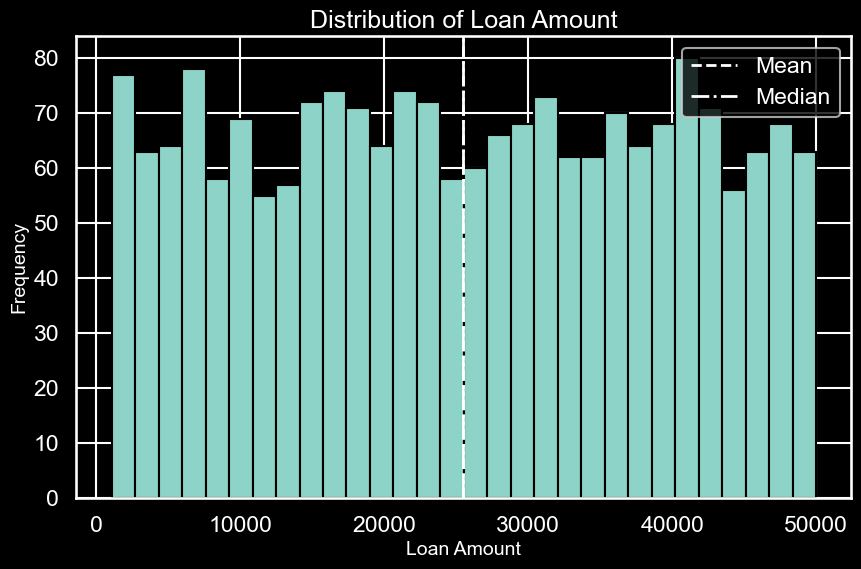

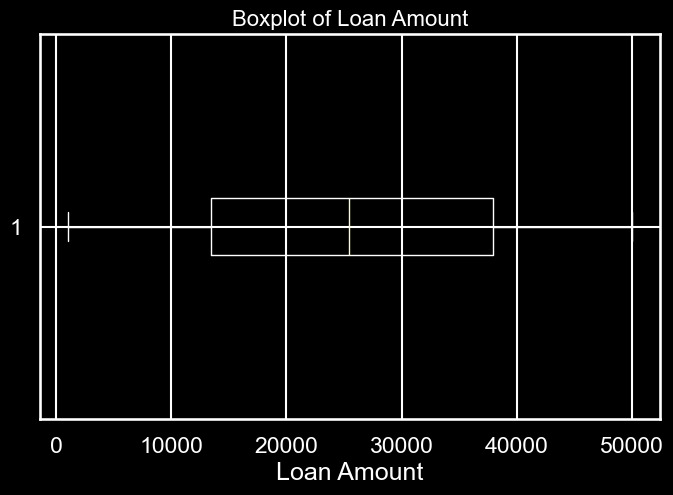


Skewness of Loan Amount : -0.01
Data is Negatively Skewed


In [8]:
# Basic Statistics
print("========== Loan Amount Statistics ==========")
print(df['Loan_Amount'].describe())

# Mean, Median, Mode
mean_value = df['Loan_Amount'].mean()
median_value = df['Loan_Amount'].median()
mode_value = df['Loan_Amount'].mode()[0]

print(f"\nMean Loan Amount   : {mean_value:.2f}")
print(f"Median Loan Amount : {median_value:.2f}")
print(f"Mode Loan Amount   : {mode_value}")

# =====================================
# Histogram Plot
# =====================================

plt.figure(figsize=(10,6))

plt.hist(
    df['Loan_Amount'],
    bins=30,
    edgecolor='black'
)

plt.axvline(mean_value, linestyle='--', linewidth=2, label='Mean')
plt.axvline(median_value, linestyle='-.', linewidth=2, label='Median')

plt.title('Distribution of Loan Amount', fontsize=18)
plt.xlabel('Loan Amount', fontsize=14)
plt.ylabel('Frequency', fontsize=14)

plt.legend()
plt.grid(True)

plt.show()

# =====================================
# Boxplot for Outlier Detection
# =====================================

plt.figure(figsize=(8,5))

plt.boxplot(df['Loan_Amount'], vert=False)

plt.title('Boxplot of Loan Amount', fontsize=16)
plt.xlabel('Loan Amount')

plt.grid(True)

plt.show()

# =====================================
# Skewness Check
# =====================================

skewness = df['Loan_Amount'].skew()

print(f"\nSkewness of Loan Amount : {skewness:.2f}")

if skewness > 0:
    print("Data is Positively Skewed")
elif skewness < 0:
    print("Data is Negatively Skewed")
else:
    print("Data is Normally Distributed")

# Findings
- The loan amount distribution appears moderately uniform, with applicant frequencies ranging between 55 and 80, while the median loan amount is approximately ₹25,000.

- The boxplot indicates a balanced spread of loan amounts with no significant outliers, suggesting consistency in the approved loan distribution.

=========== INCOME ANALYSIS ===========
count      2000.000000
mean      84533.585000
std       37771.169751
min       20155.000000
25%       50925.250000
50%       84073.500000
75%      117523.250000
max      149992.000000
Name: Income, dtype: float64

Mean Income : 84533.585
Median Income : 84073.5
Mode Income : 20661
Skewness : 0.042257072051863166


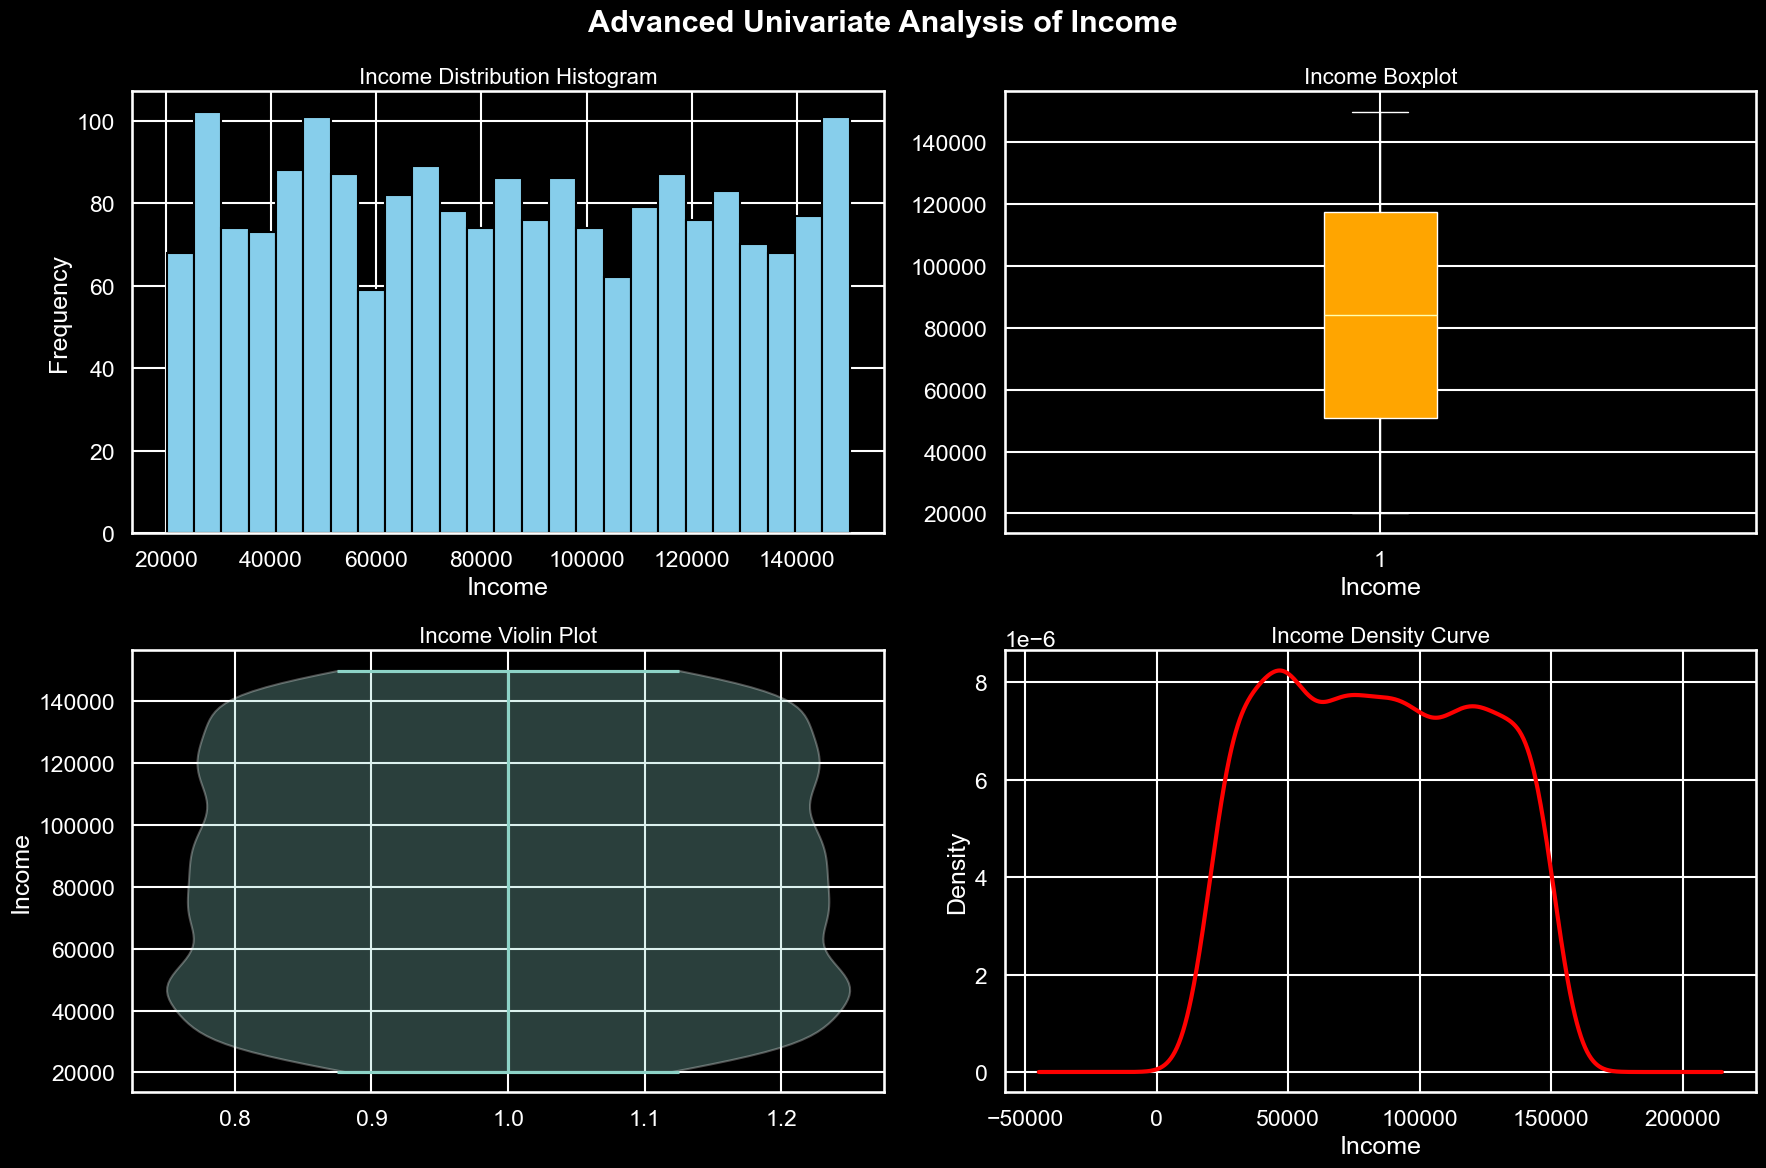

In [9]:

# ==========================================

print("=========== INCOME ANALYSIS ===========")

print(df['Income'].describe())

print("\nMean Income :", df['Income'].mean())
print("Median Income :", df['Income'].median())
print("Mode Income :", df['Income'].mode()[0])
print("Skewness :", df['Income'].skew())

# ==========================================
# Create Figure Layout
# ==========================================

fig = plt.figure(figsize=(18,12))

# ==========================================
# 1. Histogram
# ==========================================

ax1 = fig.add_subplot(2,2,1)

ax1.hist(
    df['Income'],
    bins=25,
    color='skyblue',
    edgecolor='black'
)

ax1.set_title("Income Distribution Histogram", fontsize=16)
ax1.set_xlabel("Income")
ax1.set_ylabel("Frequency")

# ==========================================
# 2. Boxplot
# ==========================================

ax2 = fig.add_subplot(2,2,2)

ax2.boxplot(
    df['Income'],
    patch_artist=True,
    boxprops=dict(facecolor='orange')
)

ax2.set_title("Income Boxplot", fontsize=16)
ax2.set_xlabel("Income")

# ==========================================
# 3. Violin Plot
# ==========================================

ax3 = fig.add_subplot(2,2,3)

ax3.violinplot(df['Income'])

ax3.set_title("Income Violin Plot", fontsize=16)
ax3.set_ylabel("Income")

# ==========================================
# 4. Density Curve (Line Graph)
# ==========================================

ax4 = fig.add_subplot(2,2,4)

df['Income'].plot(
    kind='density',
    color='red',
    linewidth=3,
    ax=ax4
)

ax4.set_title("Income Density Curve", fontsize=16)
ax4.set_xlabel("Income")

# ==========================================
# Final Layout
# ==========================================

plt.suptitle(
    "Advanced Univariate Analysis of Income",
    fontsize=22,
    fontweight='bold'
)

plt.tight_layout()

plt.show()

##  Findings
The income distribution is approximately symmetric, with a mean income of 84,533 and a median income of 84,073, while the skewness value of 0.04 indicates minimal skewness in the data.

The boxplot and histogram show that most applicants’ incomes are concentrated between ₹50,000 and ₹1,20,000, with no significant outliers observed in the dataset.

* Most applicant incomes are concentrated between ₹50,000 and ₹1,20,000 with a balanced distribution.
* The density curve shows minimal skewness and no significant outliers in the income data.


=========== LOAN TERM ANALYSIS ===========
count    2000.00000
mean       35.47800
std        16.98587
min        12.00000
25%        24.00000
50%        36.00000
75%        48.00000
max        60.00000
Name: Loan_Term, dtype: float64

Mean Loan Term : 35.478
Median Loan Term : 36.0
Mode Loan Term : 24
Skewness : 0.06530134404728842


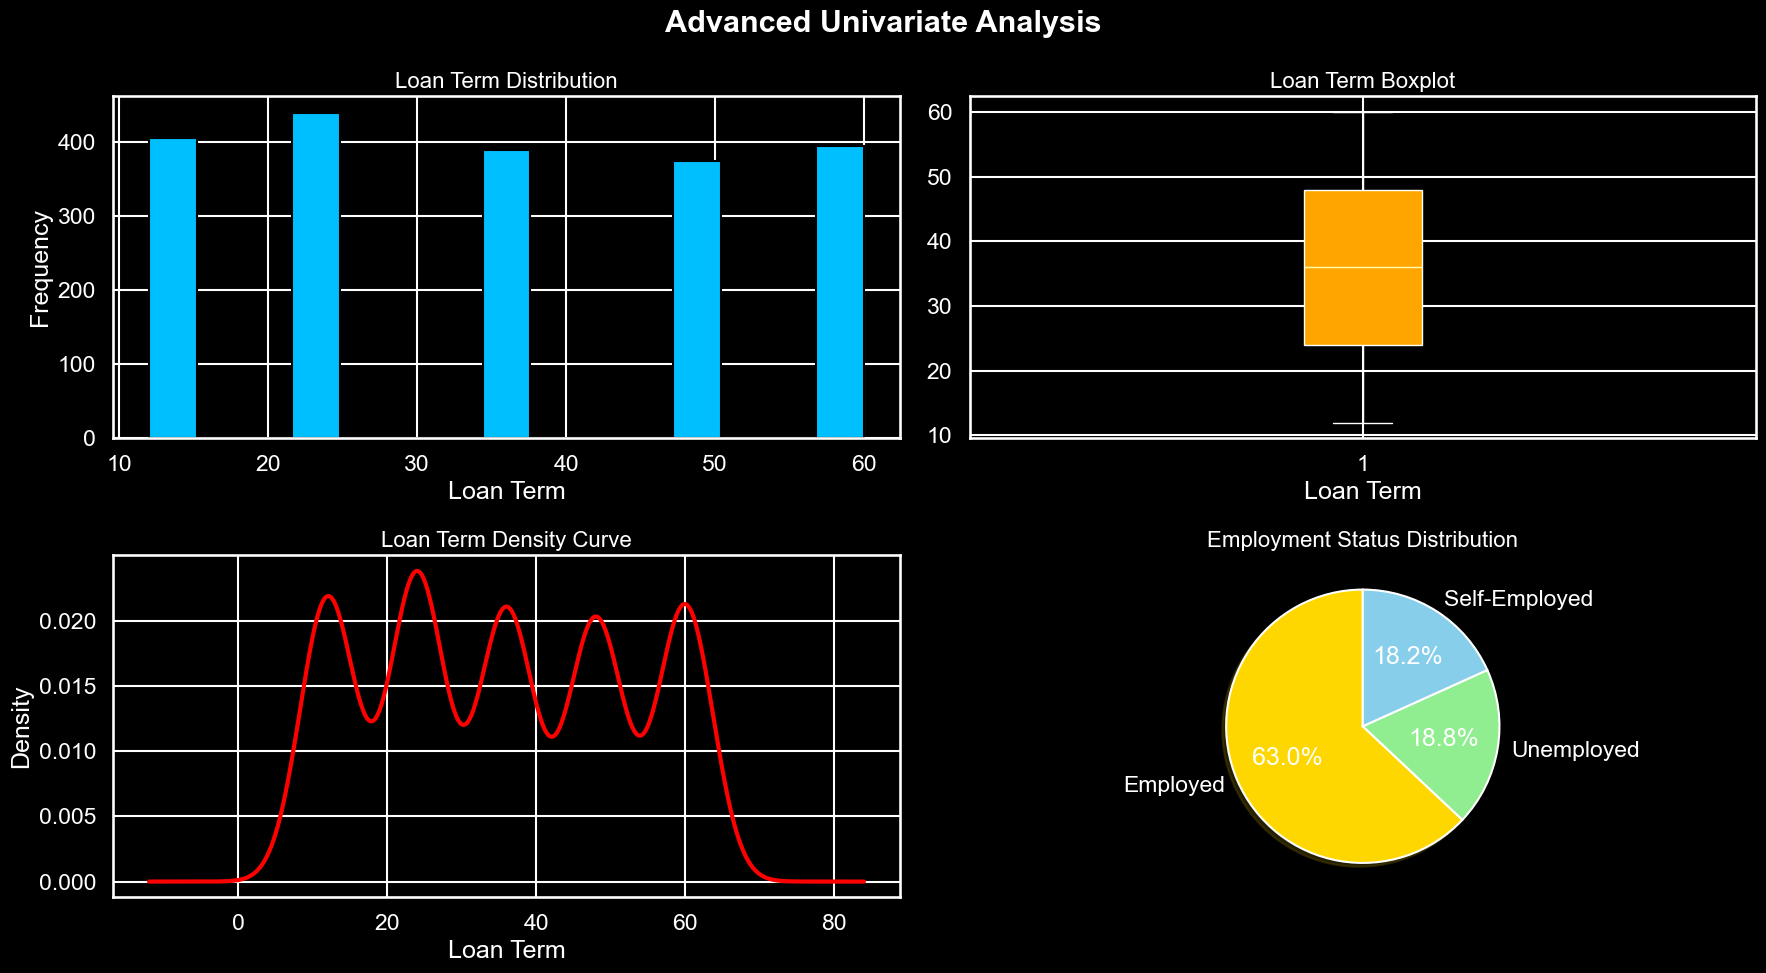

In [10]:
print("=========== LOAN TERM ANALYSIS ===========")

print(df['Loan_Term'].describe())

print("\nMean Loan Term :", df['Loan_Term'].mean())
print("Median Loan Term :", df['Loan_Term'].median())
print("Mode Loan Term :", df['Loan_Term'].mode()[0])
print("Skewness :", df['Loan_Term'].skew())

# ====================================================
# Figure Layout
# ====================================================

fig = plt.figure(figsize=(18,10))

# ====================================================
# 1. Histogram of Loan Term
# ====================================================

ax1 = fig.add_subplot(2,2,1)

ax1.hist(
    df['Loan_Term'],
    bins=15,
    color='deepskyblue',
    edgecolor='black'
)

ax1.set_title("Loan Term Distribution", fontsize=16)
ax1.set_xlabel("Loan Term")
ax1.set_ylabel("Frequency")

# ====================================================
# 2. Boxplot of Loan Term
# ====================================================

ax2 = fig.add_subplot(2,2,2)

ax2.boxplot(
    df['Loan_Term'],
    patch_artist=True,
    boxprops=dict(facecolor='orange')
)

ax2.set_title("Loan Term Boxplot", fontsize=16)
ax2.set_xlabel("Loan Term")

# ====================================================
# 3. Density Plot
# ====================================================

ax3 = fig.add_subplot(2,2,3)

df['Loan_Term'].plot(
    kind='density',
    color='red',
    linewidth=3,
    ax=ax3
)

ax3.set_title("Loan Term Density Curve", fontsize=16)
ax3.set_xlabel("Loan Term")

# ====================================================
# 4. Employment Status Pie Chart
# ====================================================

ax4 = fig.add_subplot(2,2,4)

employment_counts = df['Employment_Status'].value_counts()

colors = ['gold', 'lightgreen', 'skyblue']

ax4.pie(
    employment_counts,
    labels=employment_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    shadow=True,
    startangle=90
)

ax4.set_title("Employment Status Distribution", fontsize=16)

# ====================================================
# Final Title & Layout
# ====================================================

plt.suptitle(
    "Advanced Univariate Analysis",
    fontsize=22,
    fontweight='bold'
)

plt.tight_layout()

plt.show()

# Findings
- Loan terms are evenly distributed across different durations, with most values centered around 24 to 48 months.
- The boxplot and density curve indicate a balanced distribution with very low skewness and no major outliers.
- Overall, the loan term data shows stable variation and consistent applicant repayment preferences.

=============== DATASET INFO ===============

Dataset Shape : (2000, 7)

Column Names :
Index(['Age', 'Income', 'Credit_Score', 'Loan_Amount', 'Loan_Term',
       'Employment_Status', 'Loan_Approved'],
      dtype='object')

Missing Values :
Age                  0
Income               0
Credit_Score         0
Loan_Amount          0
Loan_Term            0
Employment_Status    0
Loan_Approved        0
dtype: int64

Data Types :
Age                   int64
Income                int64
Credit_Score          int64
Loan_Amount           int64
Loan_Term             int64
Employment_Status    object
Loan_Approved         int64
dtype: object


C:\Users\lenovo\AppData\Local\Temp\ipykernel_11344\2662002505.py:68: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot(


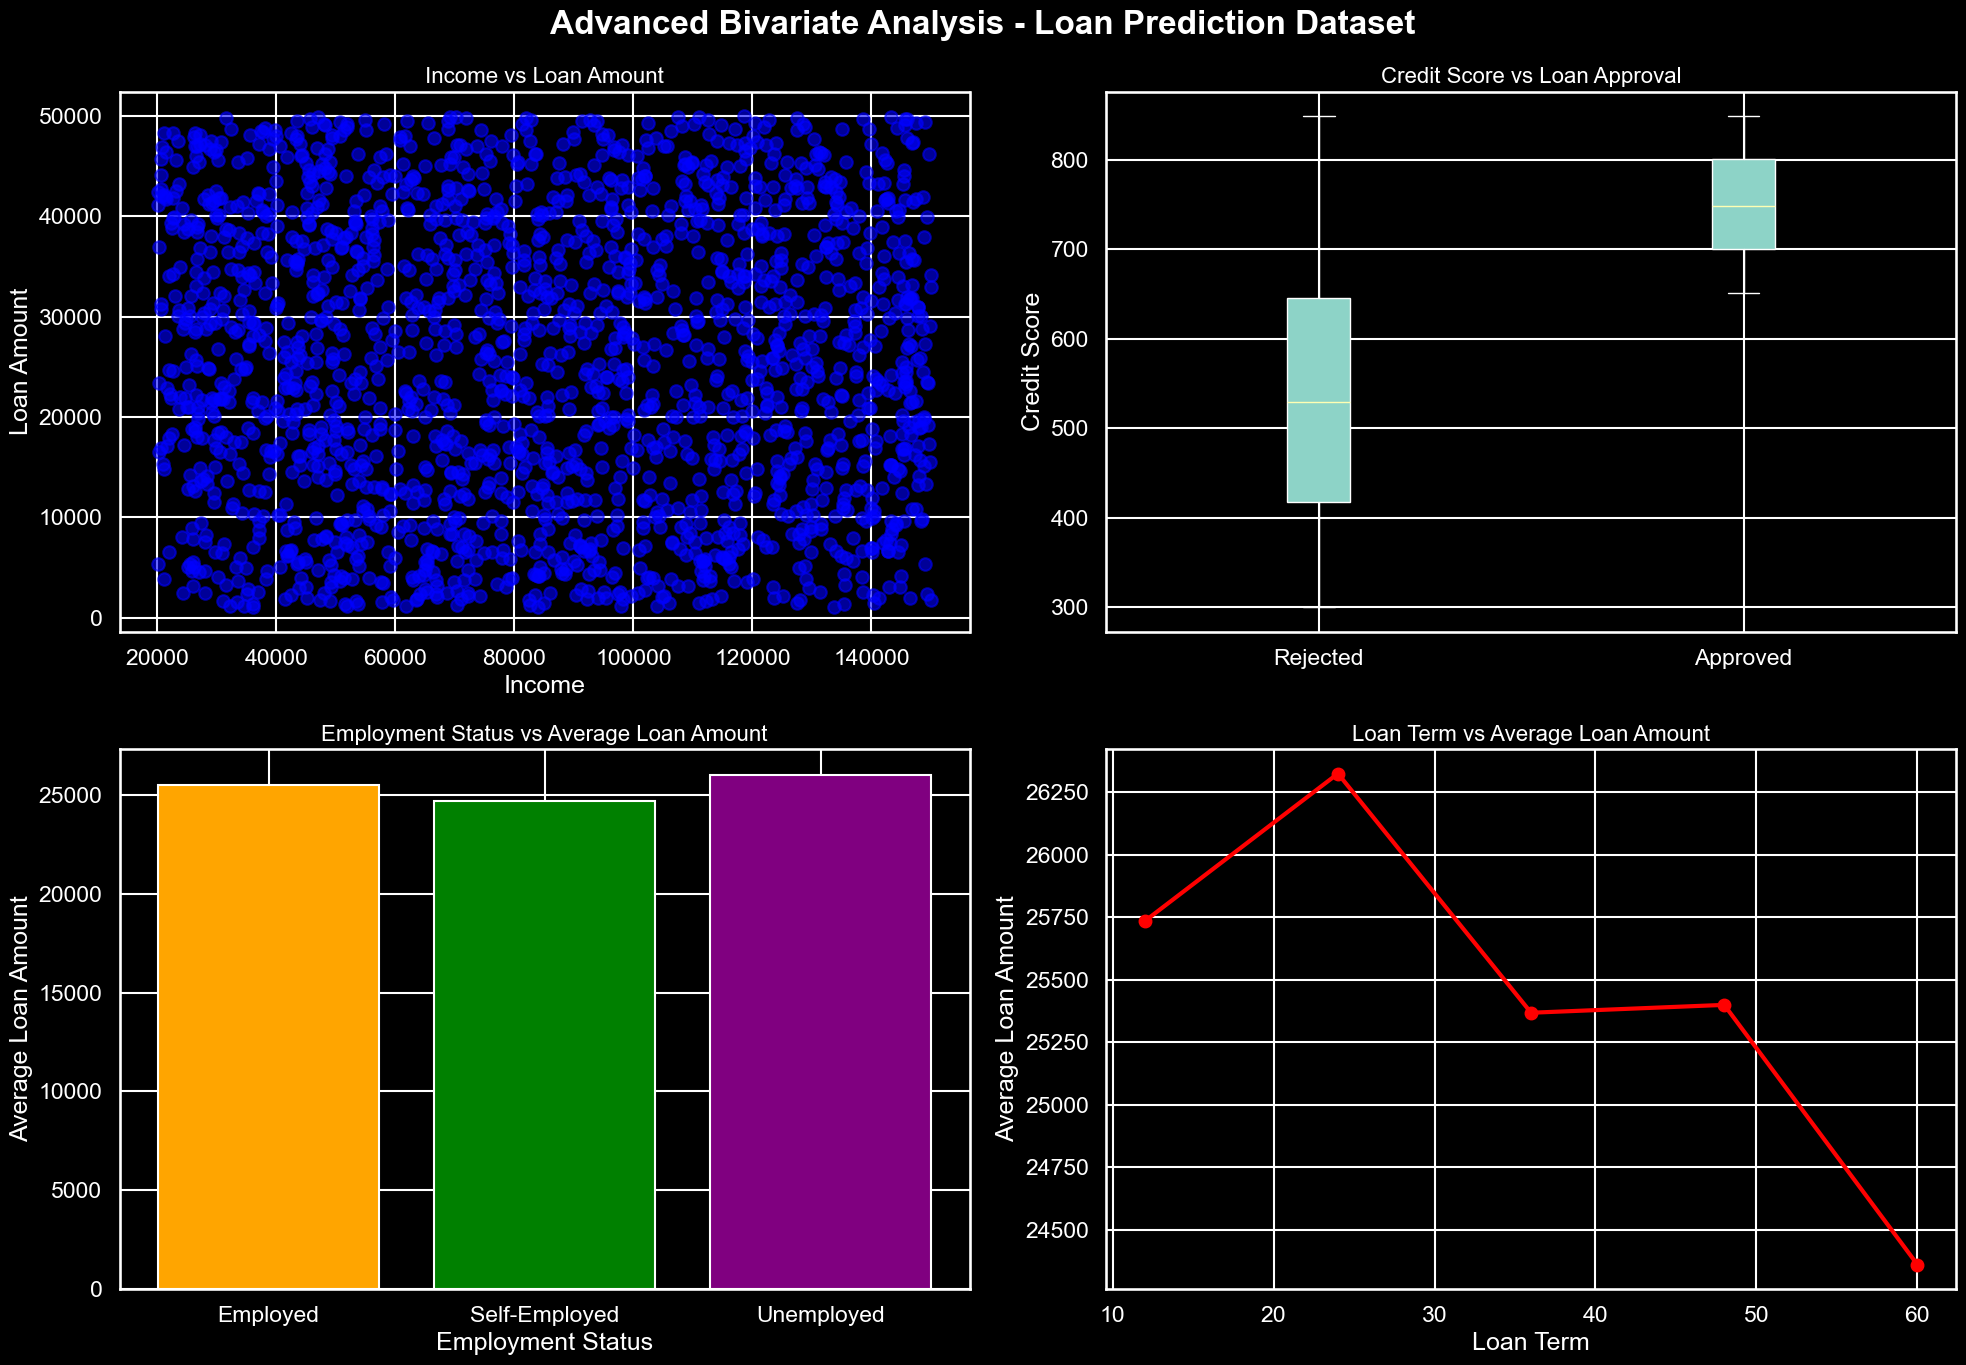


=============== CORRELATION MATRIX ===============
                    Age    Income  Credit_Score  Loan_Amount  Loan_Term  \
Age            1.000000  0.021820      0.013135    -0.009203   0.034990   
Income         0.021820  1.000000     -0.033512    -0.018823   0.034360   
Credit_Score   0.013135 -0.033512      1.000000    -0.023698  -0.005800   
Loan_Amount   -0.009203 -0.018823     -0.023698     1.000000  -0.037309   
Loan_Term      0.034990  0.034360     -0.005800    -0.037309   1.000000   
Loan_Approved  0.051829  0.182107      0.495666    -0.336799   0.007392   

               Loan_Approved  
Age                 0.051829  
Income              0.182107  
Credit_Score        0.495666  
Loan_Amount        -0.336799  
Loan_Term           0.007392  
Loan_Approved       1.000000  


In [11]:
# =========================================================
# ADVANCED BIVARIATE ANALYSIS
# Loan Prediction Dataset
# =========================================================

import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# Load Dataset
# =========================================================

df = pd.read_csv("loan_prediction_dataset.csv")

# =========================================================
# Dataset Overview
# =========================================================

print("=============== DATASET INFO ===============")

print("\nDataset Shape :", df.shape)

print("\nColumn Names :")
print(df.columns)

print("\nMissing Values :")
print(df.isnull().sum())

print("\nData Types :")
print(df.dtypes)

# =========================================================
# BIVARIATE ANALYSIS
# =========================================================

fig = plt.figure(figsize=(20,14))

# =========================================================
# 1. Income vs Loan Amount
# Scatter Plot
# =========================================================

ax1 = fig.add_subplot(2,2,1)

ax1.scatter(
    df['Income'],
    df['Loan_Amount'],
    color='blue',
    alpha=0.6
)

ax1.set_title("Income vs Loan Amount", fontsize=16)
ax1.set_xlabel("Income")
ax1.set_ylabel("Loan Amount")

# =========================================================
# 2. Credit Score vs Loan Approved
# Boxplot
# =========================================================

ax2 = fig.add_subplot(2,2,2)

approved_data = [
    df[df['Loan_Approved'] == 0]['Credit_Score'],
    df[df['Loan_Approved'] == 1]['Credit_Score']
]

ax2.boxplot(
    approved_data,
    patch_artist=True,
    labels=['Rejected', 'Approved']
)

ax2.set_title("Credit Score vs Loan Approval", fontsize=16)
ax2.set_ylabel("Credit Score")

# =========================================================
# 3. Employment Status vs Loan Amount
# Bar Chart
# =========================================================

ax3 = fig.add_subplot(2,2,3)

employment_loan = df.groupby('Employment_Status')['Loan_Amount'].mean()

ax3.bar(
    employment_loan.index,
    employment_loan.values,
    color=['orange', 'green', 'purple']
)

ax3.set_title("Employment Status vs Average Loan Amount", fontsize=16)
ax3.set_xlabel("Employment Status")
ax3.set_ylabel("Average Loan Amount")

# =========================================================
# 4. Loan Term vs Loan Amount
# Line Plot
# =========================================================

ax4 = fig.add_subplot(2,2,4)

loan_term_data = df.groupby('Loan_Term')['Loan_Amount'].mean()

ax4.plot(
    loan_term_data.index,
    loan_term_data.values,
    marker='o',
    linewidth=3,
    color='red'
)

ax4.set_title("Loan Term vs Average Loan Amount", fontsize=16)
ax4.set_xlabel("Loan Term")
ax4.set_ylabel("Average Loan Amount")

# =========================================================
# Final Design
# =========================================================

plt.suptitle(
    "Advanced Bivariate Analysis - Loan Prediction Dataset",
    fontsize=24,
    fontweight='bold'
)

plt.tight_layout()

plt.show()

# =========================================================
# Correlation Matrix
# =========================================================

print("\n=============== CORRELATION MATRIX ===============")

correlation = df.corr(numeric_only=True)

print(correlation)

# =========================================================
# Findings
# =========================================================


## KEY FINDINGS
- * Applicants with credit scores around **700–850** show higher loan approval rates, while rejected applicants mostly fall between **400–650**.
- * Average loan amounts are nearly similar across employment groups, ranging from approximately **₹24,500 to ₹26,000**.
- * Loan amounts vary slightly across loan terms, with the highest average near **24 months (~₹26,300)** and the lowest near **60 months (~₹24,300)**.


# multyvarite

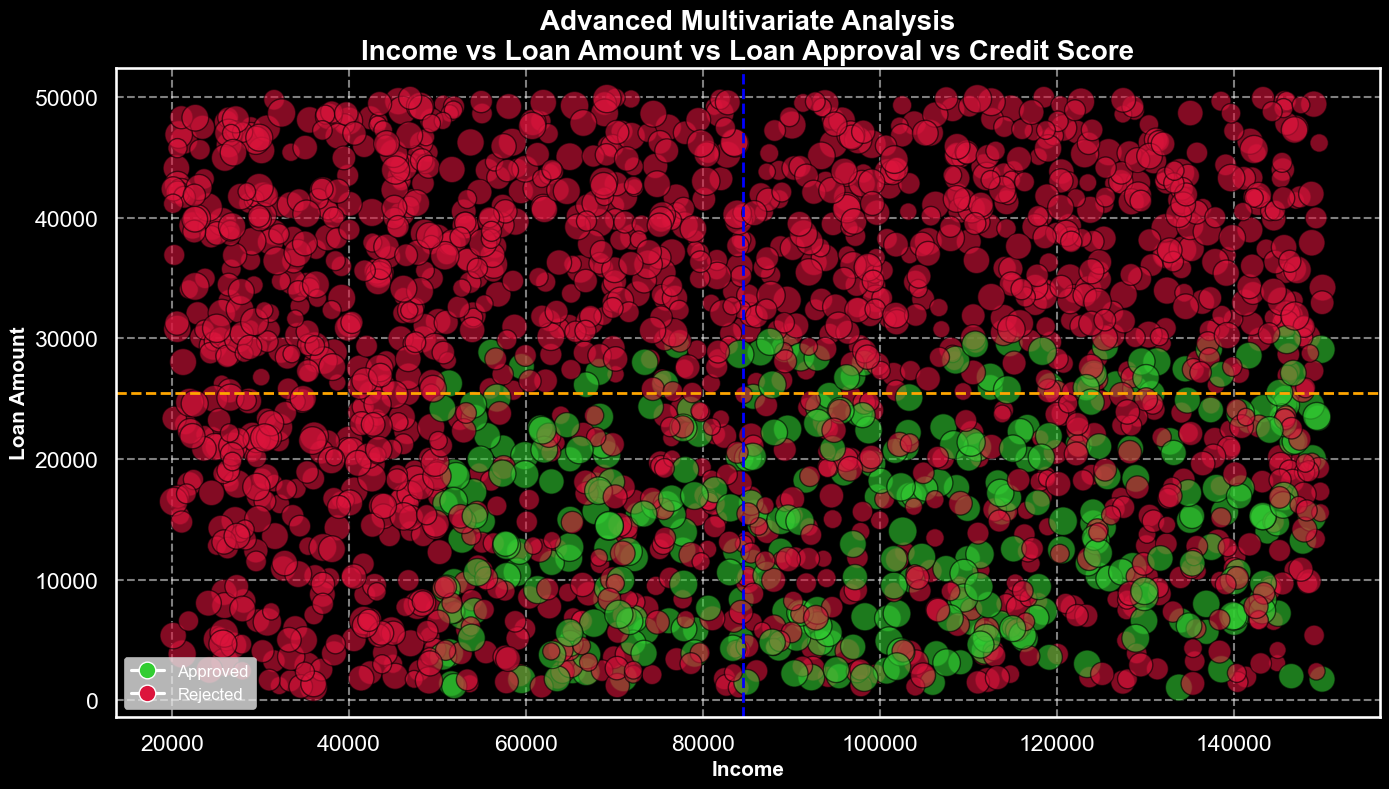

In [12]:
# ============================================================
# ULTRA ADVANCED MULTIVARIATE ANALYSIS
# Income vs Loan Amount vs Loan Approval
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# Load Dataset
# ============================================================

df = pd.read_csv("loan_prediction_dataset.csv")

# ============================================================
# Create Figure
# ============================================================

plt.figure(figsize=(14,8))

# ============================================================
# Create Bubble Size using Credit Score
# ============================================================

bubble_size = df['Credit_Score'] / 2

# ============================================================
# Color Mapping for Loan Approval
# ============================================================

colors = df['Loan_Approved'].map({
    1: 'limegreen',
    0: 'crimson'
})

# ============================================================
# Scatter Plot
# ============================================================

scatter = plt.scatter(
    df['Income'],
    df['Loan_Amount'],
    
    c=colors,
    
    s=bubble_size,
    
    alpha=0.6,
    
    edgecolors='black',
    
    linewidths=1
)

# ============================================================
# Mean Lines
# ============================================================

income_mean = df['Income'].mean()
loan_mean = df['Loan_Amount'].mean()

plt.axvline(
    income_mean,
    color='blue',
    linestyle='--',
    linewidth=2,
    label='Average Income'
)

plt.axhline(
    loan_mean,
    color='orange',
    linestyle='--',
    linewidth=2,
    label='Average Loan Amount'
)

# ============================================================
# Background Style
# ============================================================

plt.style.use('ggplot')

# ============================================================
# Titles & Labels
# ============================================================

plt.title(
    "Advanced Multivariate Analysis\nIncome vs Loan Amount vs Loan Approval vs Credit Score",
    fontsize=20,
    fontweight='bold'
)

plt.xlabel(
    "Income",
    fontsize=15,
    fontweight='bold'
)

plt.ylabel(
    "Loan Amount",
    fontsize=15,
    fontweight='bold'
)

# ============================================================
# Custom Legend
# ============================================================

from matplotlib.lines import Line2D

legend_elements = [

    Line2D(
        [0],
        [0],
        marker='o',
        color='w',
        label='Approved',
        markerfacecolor='limegreen',
        markersize=12
    ),

    Line2D(
        [0],
        [0],
        marker='o',
        color='w',
        label='Rejected',
        markerfacecolor='crimson',
        markersize=12
    )
]

plt.legend(
    handles=legend_elements,
    fontsize=12
)

# ============================================================
# Grid & Layout
# ============================================================

plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()

# ============================================================
# Show Plot
# ============================================================

plt.show()

# ============================================================
# Insights
# ============================================================


## KEY INSIGHTS 
- Applicants with income above ₹80,000 and loan amounts below ₹25,000 show a higher concentration of approved loans.
- Rejected applications are more common among applicants with income below ₹50,000 and higher loan amounts above ₹25,000.
- Credit score and income together strongly influence loan approval, with approved applicants clustered in higher income and lower risk regions.

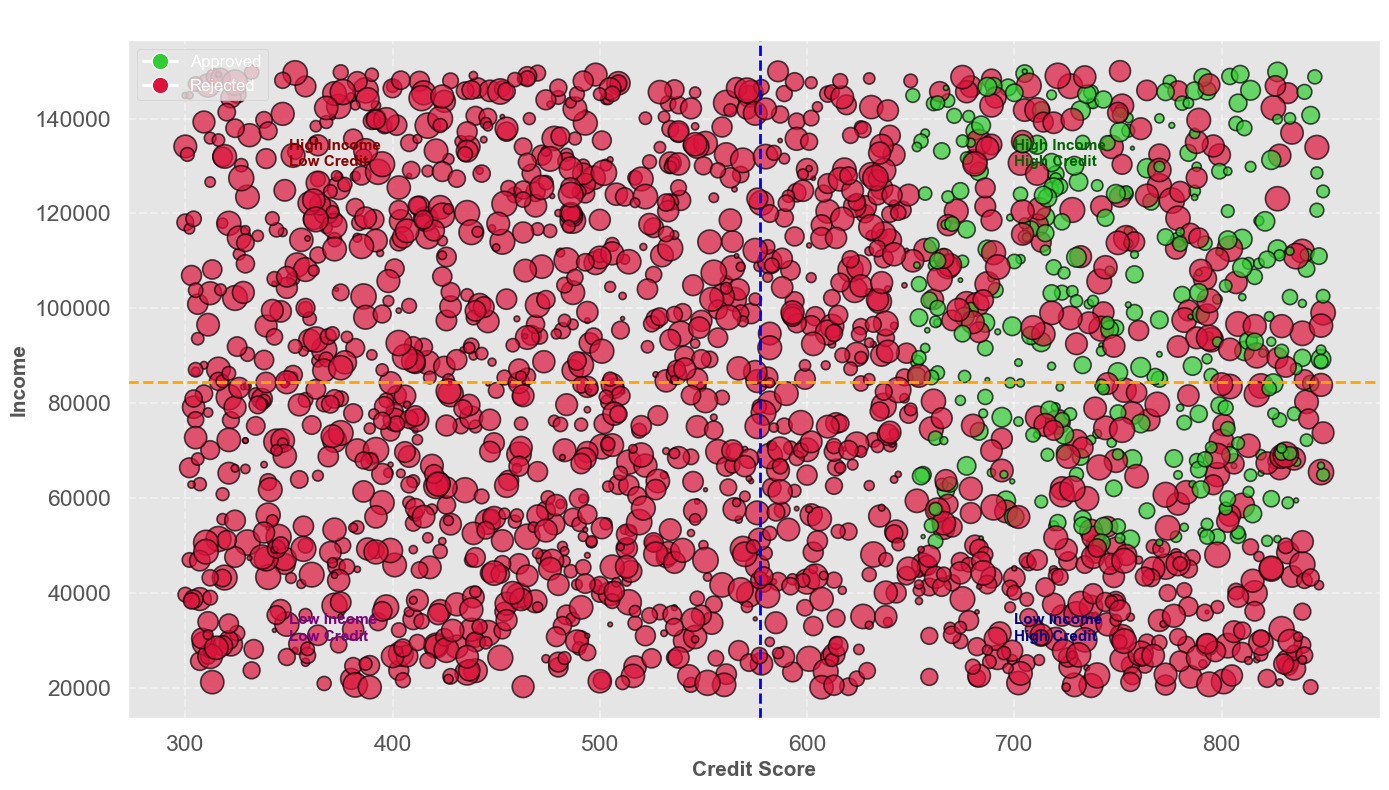

In [13]:
# ==========================================================
# ULTRA ADVANCED MULTIVARIATE ANALYSIS
# Credit Score vs Income vs Loan Approval
# ==========================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# ==========================================================
# Load Dataset
# ==========================================================

df = pd.read_csv("loan_prediction_dataset.csv")

# ==========================================================
# Figure Size & Style
# ==========================================================

plt.style.use('ggplot')

fig, ax = plt.subplots(figsize=(14,8))

# ==========================================================
# Bubble Size using Loan Amount
# ==========================================================

bubble_size = df['Loan_Amount'] / 150

# ==========================================================
# Color Mapping
# ==========================================================

colors = df['Loan_Approved'].map({
    1: 'limegreen',
    0: 'crimson'
})

# ==========================================================
# Scatter Plot
# ==========================================================

scatter = ax.scatter(
    
    df['Credit_Score'],
    
    df['Income'],
    
    s=bubble_size,
    
    c=colors,
    
    alpha=0.7,
    
    edgecolors='black',
    
    linewidths=1.2
)

# ==========================================================
# Mean Lines
# ==========================================================

credit_mean = df['Credit_Score'].mean()
income_mean = df['Income'].mean()

ax.axvline(
    credit_mean,
    color='blue',
    linestyle='--',
    linewidth=2,
    label='Average Credit Score'
)

ax.axhline(
    income_mean,
    color='orange',
    linestyle='--',
    linewidth=2,
    label='Average Income'
)

# ==========================================================
# Quadrant Text
# ==========================================================

ax.text(
    350,
    130000,
    "High Income\nLow Credit",
    fontsize=11,
    fontweight='bold',
    color='darkred'
)

ax.text(
    700,
    130000,
    "High Income\nHigh Credit",
    fontsize=11,
    fontweight='bold',
    color='darkgreen'
)

ax.text(
    350,
    30000,
    "Low Income\nLow Credit",
    fontsize=11,
    fontweight='bold',
    color='purple'
)

ax.text(
    700,
    30000,
    "Low Income\nHigh Credit",
    fontsize=11,
    fontweight='bold',
    color='navy'
)

# ==========================================================
# Titles & Labels
# ==========================================================

ax.set_title(
    "Advanced Credit Score vs Income Analysis",
    fontsize=22,
    fontweight='bold'
)

ax.set_xlabel(
    "Credit Score",
    fontsize=15,
    fontweight='bold'
)

ax.set_ylabel(
    "Income",
    fontsize=15,
    fontweight='bold'
)

# ==========================================================
# Legend
# ==========================================================

legend_elements = [

    Line2D(
        [0],
        [0],
        marker='o',
        color='w',
        label='Approved',
        markerfacecolor='limegreen',
        markersize=12
    ),

    Line2D(
        [0],
        [0],
        marker='o',
        color='w',
        label='Rejected',
        markerfacecolor='crimson',
        markersize=12
    )
]

ax.legend(
    handles=legend_elements,
    fontsize=12,
    loc='upper left'
)

# ==========================================================
# Grid Customization
# ==========================================================

ax.grid(
    True,
    linestyle='--',
    alpha=0.4
)

# ==========================================================
# Layout
# ==========================================================

plt.tight_layout()

# ==========================================================
# Show Plot
# ==========================================================

plt.show()

# ==========================================================
# Insights
# ==========================================================



KEY INSIGHTS
* The scatter plot shows that applicants with **higher credit scores (above ~580)** and **higher income (above ~85K)** have a greater number of approved loans (green points).
* Most rejected applications (red points) are concentrated in the **low credit score and low income region**, indicating these factors strongly affect loan approval.
* Applicants with high income but poor credit score are still frequently rejected, showing that **credit score has a major impact** on approval decisions.
* The graph clearly highlights that the combination of **high income + strong credit history** results in the highest loan approval probability.


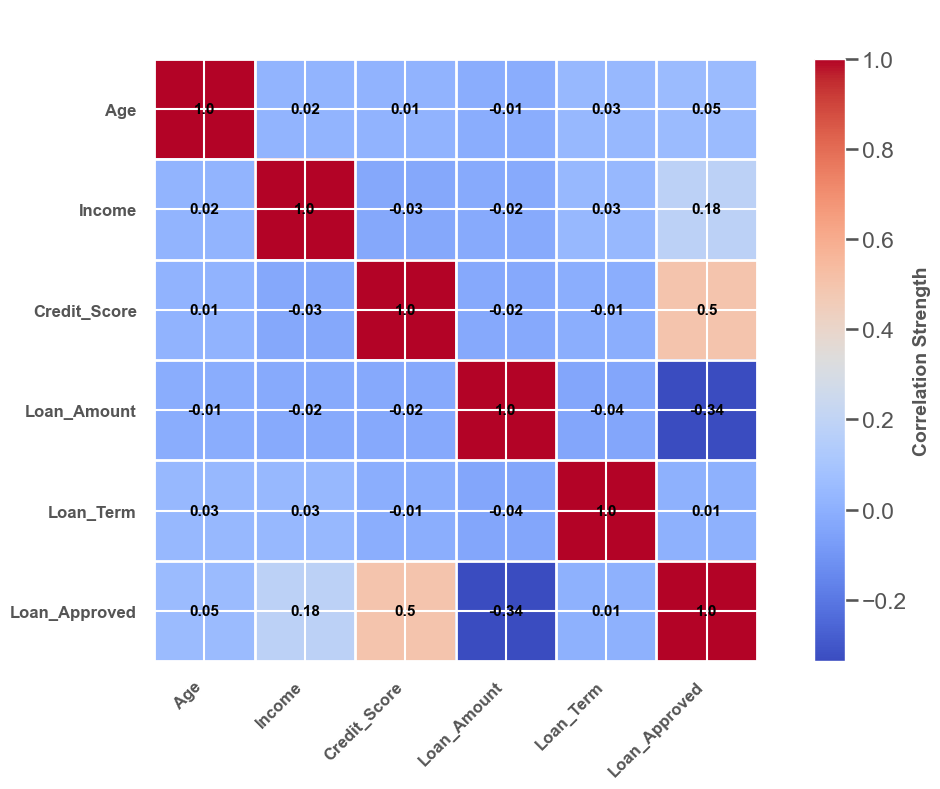

In [14]:
#
# Correlation Matrix
# ==========================================================

corr_matrix = df.corr(numeric_only=True)

# ==========================================================
# Figure Setup
# ==========================================================

fig, ax = plt.subplots(figsize=(12,8))

# ==========================================================
# Create Heatmap
# ==========================================================

heatmap = ax.imshow(
    corr_matrix,
    
    cmap='coolwarm',
    
    interpolation='nearest'
)

# ==========================================================
# Add Color Bar
# ==========================================================

cbar = plt.colorbar(heatmap)

cbar.set_label(
    'Correlation Strength',
    fontsize=14,
    fontweight='bold'
)

# ==========================================================
# Axis Labels
# ==========================================================

ax.set_xticks(np.arange(len(corr_matrix.columns)))
ax.set_yticks(np.arange(len(corr_matrix.columns)))

ax.set_xticklabels(
    corr_matrix.columns,
    rotation=45,
    ha='right',
    fontsize=12,
    fontweight='bold'
)

ax.set_yticklabels(
    corr_matrix.columns,
    fontsize=12,
    fontweight='bold'
)

# ==========================================================
# Add Correlation Values Inside Boxes
# ==========================================================

for i in range(len(corr_matrix.columns)):
    
    for j in range(len(corr_matrix.columns)):
        
        value = round(corr_matrix.iloc[i, j], 2)
        
        ax.text(
            j,
            i,
            value,
            ha='center',
            va='center',
            color='black',
            fontsize=11,
            fontweight='bold'
        )

# ==========================================================
# Title
# ==========================================================

plt.title(
    "Advanced Correlation Heatmap Analysis",
    fontsize=22,
    fontweight='bold',
    pad=20
)

# ==========================================================
# Grid Style
# ==========================================================

ax.set_xticks(
    np.arange(-.5, len(corr_matrix.columns), 1),
    minor=True
)

ax.set_yticks(
    np.arange(-.5, len(corr_matrix.columns), 1),
    minor=True
)

ax.grid(
    which='minor',
    color='white',
    linestyle='-',
    linewidth=2
)

# Remove minor tick marks
ax.tick_params(which='minor', bottom=False, left=False)

# ==========================================================
# Tight Layout
# ==========================================================

plt.tight_layout()

# ==========================================================
# Show Heatmap
# ==========================================================

plt.show()

# ==========================================================
# Insights
# ==========================================================


## KEY INSIGHTS
- The correlation heatmap shows that Credit Score has the strongest positive relationship with Loan Approval (0.50), indicating that applicants with better credit history are more likely to get loans approved.
- Loan Amount has a moderate negative correlation with Loan Approval (-0.34), suggesting that higher loan requests reduce the chances of approval.
- Income shows a weak positive correlation with Loan Approval (0.18), meaning higher income slightly improves approval probability but is not the most influential factor.
-  Other variables such as Age and Loan Term have very low correlations, indicating they have minimal direct impact on loan approval decisions in this dataset.

# Loan Prediction EDA Summary

## Dataset Overview
The dataset contains 2,000 records and 7 variables related to loan applicants. These features include Age, Income, Credit Score, Loan Amount, Loan Term, Employment Status, and Loan Approved. The target variable is Loan_Approved, where 0 means No and 1 means Yes.

| Variable | Description |
|---|---|
| Age | Age of the applicant |
| Income | Annual income of the customer |
| Credit_Score | Creditworthiness score |
| Loan_Amount | Amount requested for loan |
| Loan_Term | Duration of loan repayment |
| Employment_Status | Employment category |
| Loan_Approved | Target variable (0 = No, 1 = Yes) |

## Data Cleaning Note
Data cleaning is not required for this dataset because the notebook shows that all 2,000 records are complete and there are no missing values. The columns are already in the correct format, with numeric variables stored as integers and Employment_Status stored as a categorical variable. Since the dataset is clean and well-structured, the main focus of analysis can remain on feature relationships, imbalance in the target variable, and model preparation. 

However, even though full cleaning is not needed, minor preprocessing may still be useful before modeling, such as encoding categorical variables and handling class imbalance in Loan_Approved.


## Data Quality
- The dataset has 2,000 rows and 7 columns.
- There are no missing values.
- Numeric columns: Age, Income, Credit_Score, Loan_Amount, Loan_Term, Loan_Approved.
- Categorical column: Employment_Status.

## Target Distribution
The target variable is highly imbalanced. Around 1,650 loan applications were rejected and only about 350 were approved. This means the dataset has class imbalance, which should be handled before model building.

## Univariate Analysis
- **Credit_Score**: This is the most important feature. Higher credit scores are linked with higher approval chances.
- **Income**: Applicants with higher income tend to have better approval probability.
- **Loan_Amount**: Larger loan amounts may reduce the chance of approval.
- **Loan_Term**: Most values are centered around 24 to 48 months.
- **Employment_Status**: Employment type affects loan behavior and approval.
- **Age**: Age does not show a very strong direct effect on approval.

## Relationship Analysis
- Credit_Score has the strongest positive relationship with Loan_Approved.
- Loan_Amount has a negative relationship with Loan_Approved.
- Income has a weak-to-moderate positive relationship with Loan_Approved.
- Employment_Status affects approval indirectly through stability of income.
- Age and Loan_Term have little direct influence on approval.

## Correlation Insights
- Credit_Score and Loan_Approved show the highest positive correlation.
- Loan_Amount and Loan_Approved show a clear negative correlation.
- Income has a smaller positive correlation with Loan_Approved.
- Age and Loan_Term have nearly no correlation with the target.

## Business Interpretation
The approval decision seems to depend mostly on creditworthiness, income stability, and requested loan amount. Applicants with high credit scores and stable income are more likely to get approval, while large loan requests are more likely to be rejected.

## Preprocessing Suggestions
- Handle class imbalance using SMOTE, oversampling, or class weights.
- Encode Employment_Status before modeling.
- Standardize or scale numeric variables if needed.
- Check for outliers in Loan_Amount and Income.
- Consider feature engineering such as Income-to-Loan_Amount ratio.

## Conclusion
This EDA shows that Credit_Score is the most powerful predictor of loan approval. Loan_Amount is negatively related to approval, while Income has a smaller positive effect. The dataset is imbalanced, so balancing techniques should be used before training machine learning models.